In [1]:
import cooler
import cooltools
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score
from ggner_3d.cm import prepare_view_df
import pandas as pd
import numpy as np
from coolpuppy import coolpup
from ggner_3d import plotting
plotting.update_rcparams()

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

resolution = 100_000

mcool_control='/home/carlos/Clone/ggner-3d/data/degron_rad21/GSE178982_RAD21-UT_pool.mcool'
mcool_degron='/home/carlos/Clone/ggner-3d/data/degron_rad21/GSE178982_RAD21-AID_pool.mcool'

### cis decay

In [2]:
control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')

view_df = pd.DataFrame({'chrom': control_clr.chromnames,
                        'start': 0,
                        'end': control_clr.chromsizes.values,
                        'name': control_clr.chromnames}
                      )

control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers


In [3]:
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')
degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers


In [25]:
import numpy as np

def prepare_cvd(df, max_dist=None):
    cvd = df.copy()

    # Safe assignment
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed'] = np.nan
    cvd.loc[cvd['dist'] < 2, 'balanced.avg.smoothed.agg'] = np.nan

    cvd = cvd.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

    # Filter distance range early
    if max_dist is not None:
        cvd = cvd[cvd['dist_bp'] <= max_dist]
    else:
        cvd = cvd[cvd['dist_bp'] > 0]  # Ensure we don't have zero or negative distances

    # Remove NaNs before normalization
    cvd = cvd.dropna()

    # Ensure positive values only
    cvd = cvd[cvd['balanced.avg.smoothed.agg'] > 0]
    cvd = cvd[cvd['dist_bp'] > 0]

    # Normalize by AUC
    auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])
    if auc == 0 or not np.isfinite(auc):
        raise ValueError("AUC is zero or invalid — cannot normalize.")

    cvd['balanced.avg.smoothed.agg'] /= auc

    # Derivative in log-log space
    der = np.gradient(
        np.log(cvd['balanced.avg.smoothed.agg']),
        np.log(cvd['dist_bp'])
    )

    return cvd, der

control_merged, control_der = prepare_cvd(control_expected, max_dist=None)
degron_merged, degron_der = prepare_cvd(degron_expected, max_dist=None)

/tmp/ipykernel_135384/230405648.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])
/tmp/ipykernel_135384/230405648.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(cvd['balanced.avg.smoothed.agg'], cvd['dist_bp'])


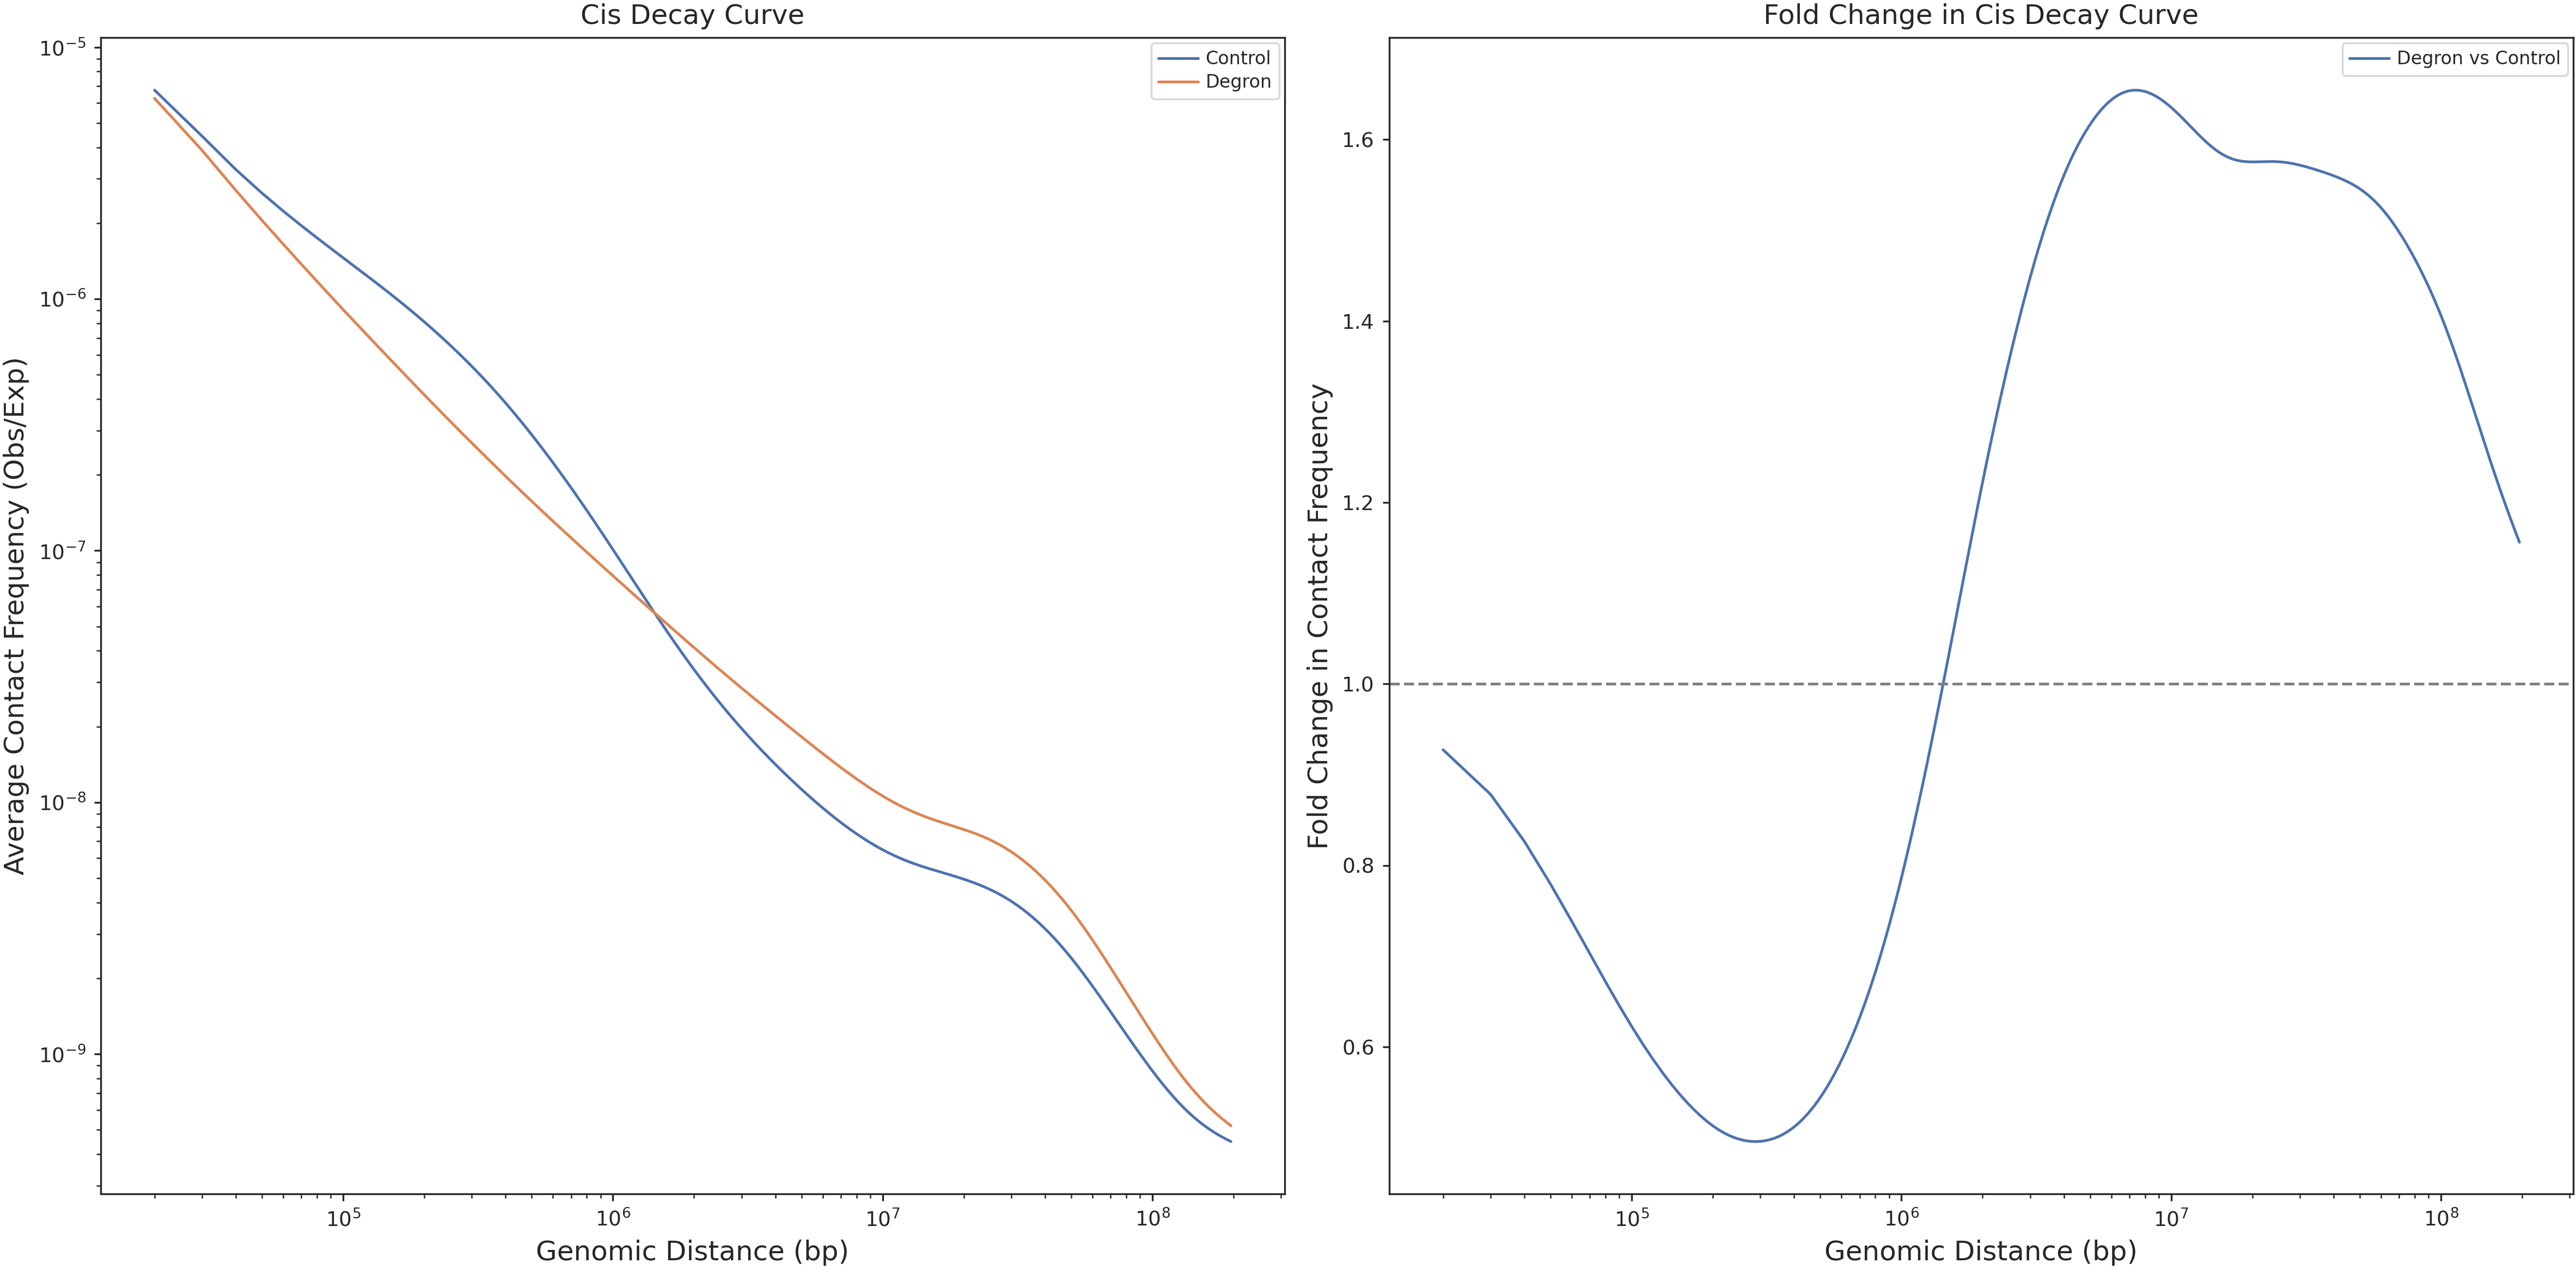

In [26]:
import seaborn as sns
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(16, 8))
sns.lineplot(x=control_merged['dist_bp'], y=control_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Control')
sns.lineplot(x=degron_merged['dist_bp'], y=degron_merged['balanced.avg.smoothed.agg'], ax=ax[0], label='Degron')

# set loglog
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('Genomic Distance (bp)')
ax[0].set_ylabel('Average Contact Frequency (Obs/Exp)')
ax[0].set_title('Cis Decay Curve')
ax[0].legend()


foldchange = degron_merged['balanced.avg.smoothed.agg'] / control_merged['balanced.avg.smoothed.agg']
sns.lineplot(x=control_merged['dist_bp'], y=foldchange, ax=ax[1], label='Degron vs Control')
ax[1].set_xscale('log')
ax[1].set_xlabel('Genomic Distance (bp)')
ax[1].set_ylabel('Fold Change in Contact Frequency')
ax[1].set_title('Fold Change in Cis Decay Curve')
# add horizontal line at y=0
ax[1].axhline(1, color='gray', linestyle='--')
ax[1].legend()

plt.tight_layout()

### compartments

In [6]:
from cooltools import eigs_cis

import multiprocess as mp
pool = mp.Pool(10)
resolution = 100_000

In [ ]:
# import bioframe
# bins = control_clr.bins()[:]
# hg38_genome = bioframe.load_fasta('/home/carlos/Clone/ggner-3d/data/degron_wapl/hg38.fa')
# gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
# gc_cov.to_csv('/home/carlos/Clone/ggner-3d/data/degron_wapl/gc_cov.tsv', sep='\t', index=False)

In [7]:
gc_cov = pd.read_csv('/home/carlos/Clone/ggner-3d/data/degron_wapl/gc_cov.tsv', sep='\t')

In [8]:
view_df = pd.DataFrame({'chrom': control_clr.chromnames,
                        'start': 0,
                        'end': control_clr.chromsizes.values,
                        'name': control_clr.chromnames}
                      )

_, eigvec_table_control = cooltools.eigs_cis(
    clr=control_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

_, eigvec_table_degron = cooltools.eigs_cis(
    clr=degron_clr,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    clr_weight_name='weight',
    sort_metric='MAD_explained',
    map=pool.map
)

In [11]:
from scipy.stats import pearsonr

bad_chroms = []
for chrom in eigvec_table_control['chrom'].unique():
    control_e1 = eigvec_table_control[eigvec_table_control['chrom'] == chrom]['E1']
    degron_e1 = eigvec_table_degron[eigvec_table_degron['chrom'] == chrom]['E1']
    both_non_na = np.isfinite(control_e1) & np.isfinite(degron_e1)

    if control_e1[both_non_na].empty or degron_e1[both_non_na].empty:
        print(f"Chromosome {chrom}: Not enough data for correlation.")
        bad_chroms.append(chrom)
        continue

    corr, pval = pearsonr(control_e1[both_non_na], degron_e1[both_non_na])
    if corr < 0.5:
        print(f"Chromosome {chrom}: Low correlation of E1 between control and degron: {corr:.4f} (p={pval:.2e})")
        bad_chroms.append(chrom)
    else:
        print(f"Chromosome {chrom}: E1 correlation between control and degron: {corr:.4f} (p={pval:.2e})")
view_df_filtered = view_df[~view_df['chrom'].isin(bad_chroms)]

Chromosome chr1: E1 correlation between control and degron: 0.7646 (p=0.00e+00)
Chromosome chr2: E1 correlation between control and degron: 0.7681 (p=0.00e+00)
Chromosome chr3: E1 correlation between control and degron: 0.9714 (p=0.00e+00)
Chromosome chr4: Low correlation of E1 between control and degron: 0.0255 (p=3.22e-01)
Chromosome chr5: E1 correlation between control and degron: 0.7589 (p=9.17e-275)
Chromosome chr6: E1 correlation between control and degron: 0.7254 (p=2.02e-239)
Chromosome chr7: E1 correlation between control and degron: 0.9764 (p=0.00e+00)
Chromosome chr8: E1 correlation between control and degron: 0.9831 (p=0.00e+00)
Chromosome chr9: Low correlation of E1 between control and degron: 0.2311 (p=3.45e-16)
Chromosome chr10: E1 correlation between control and degron: 0.9773 (p=0.00e+00)
Chromosome chr11: E1 correlation between control and degron: 0.9862 (p=0.00e+00)
Chromosome chr12: Low correlation of E1 between control and degron: 0.0458 (p=1.18e-01)
Chromosome chr

In [12]:
control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers


In [13]:
eigenvector_track_control = eigvec_table_control[['chrom','start','end','E1']].loc[~eigvec_table_control['chrom'].isin(bad_chroms)]
eigenvector_track_degron = eigvec_table_degron[['chrom','start','end','E1']].loc[~eigvec_table_degron['chrom'].isin(bad_chroms)]

N_GROUPS = 50
Q_LO, Q_HI = 0.025, 0.975

interaction_sum_c, interaction_count_c =  cooltools.saddle(
        control_clr,
        control_expected,
        eigenvector_track_control,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

interaction_sum_d, interaction_count_d =  cooltools.saddle(
        degron_clr,
        degron_expected,
        eigenvector_track_degron,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat


Text(0.5, 1.0, 'Delta Saddle Plot (Degron - Control)')

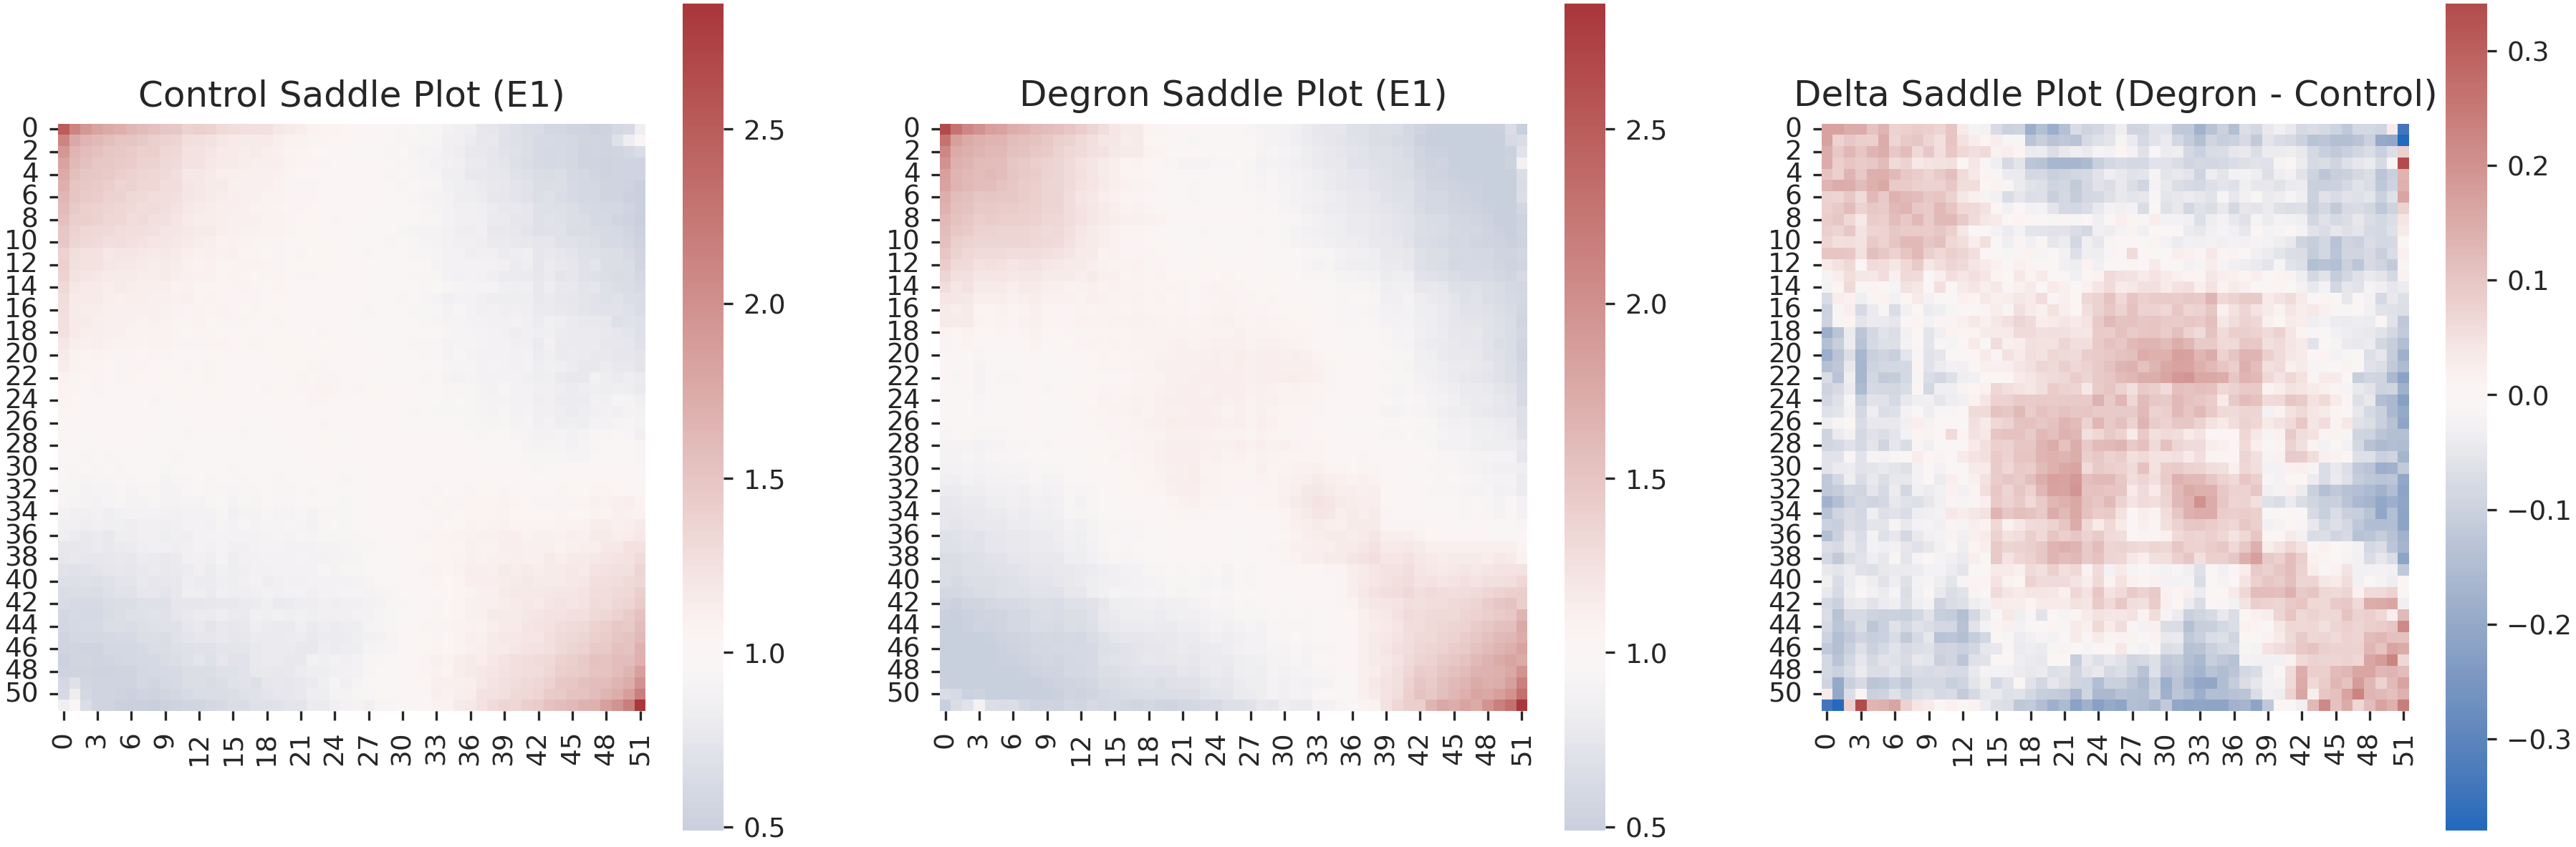

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(interaction_sum_c / interaction_count_c)
vmax = np.nanmax(interaction_sum_c / interaction_count_c)

sns.heatmap(interaction_sum_c / interaction_count_c, cmap='vlag', center=1, ax=axs[0], vmin=vmin, vmax=vmax, square=True)
axs[0].set_title('Control Saddle Plot (E1)')
sns.heatmap(interaction_sum_d / interaction_count_d, cmap='vlag', center=1, ax=axs[1], vmin=vmin, vmax=vmax, square=True)
axs[1].set_title('Degron Saddle Plot (E1)')

delta = (interaction_sum_d / interaction_count_d) - (interaction_sum_c / interaction_count_c)
sns.heatmap(delta, cmap='vlag', center=0, ax=axs[2], square=True)
axs[2].set_title('Delta Saddle Plot (Degron - Control)')

/tmp/ipykernel_135384/392936491.py:9: RuntimeWarning: divide by zero encountered in log2
  plt.step(x, np.log2(saddle_strength(saddle[0], saddle[1])), where='pre', label=name)


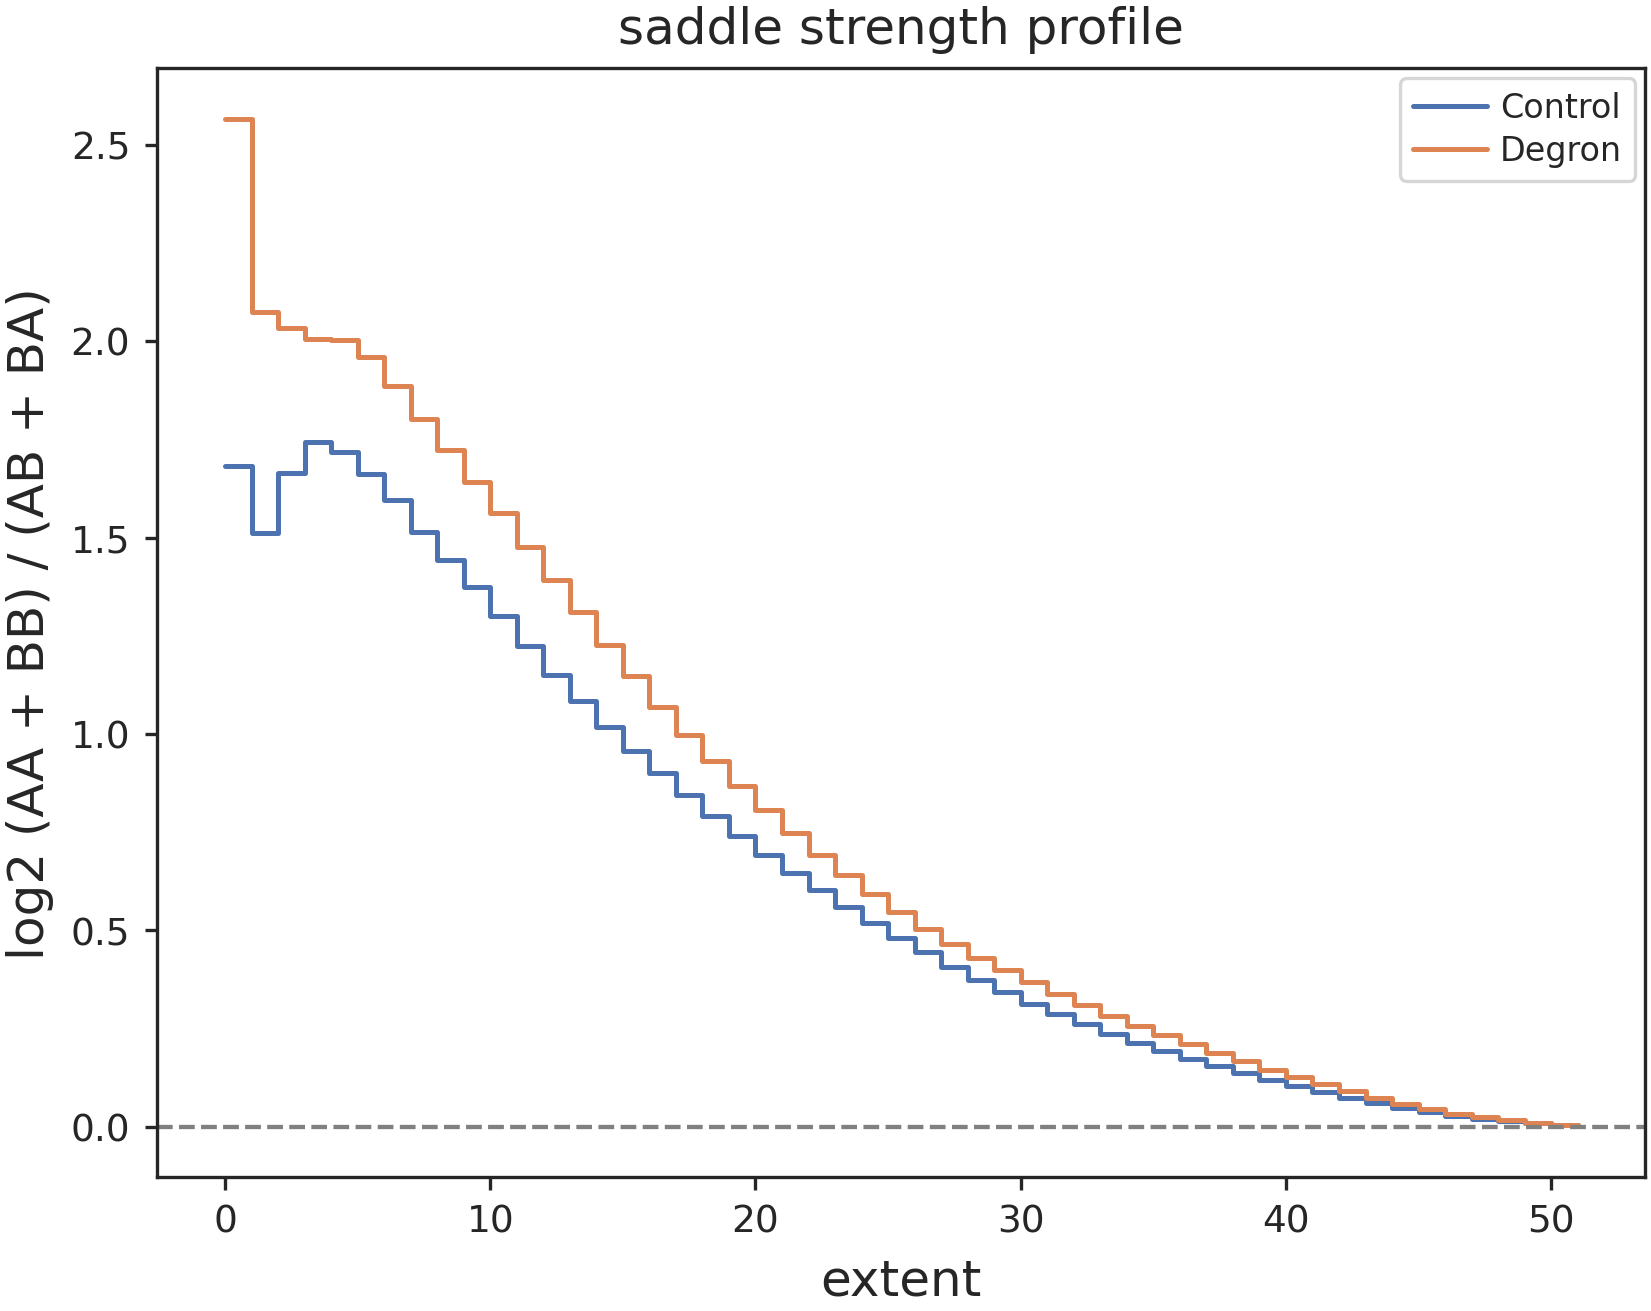

In [15]:
from cooltools.api.saddle import saddle_strength

saddle_c = (interaction_sum_c, interaction_count_c)
saddle_d = (interaction_sum_d, interaction_count_d)

for name, saddle in [('Control', saddle_c), ('Degron', saddle_d)]:
    x = np.arange(N_GROUPS + 2)

    plt.step(x, np.log2(saddle_strength(saddle[0], saddle[1])), where='pre', label=name)

    plt.xlabel('extent')
    plt.ylabel('log2 (AA + BB) / (AB + BA)')
    plt.title('saddle strength profile')
    plt.axhline(0, c='grey', ls='--', lw=1)

plt.legend()

### insulation

In [16]:
resolution = 10_000
window = 500_000

control_clr = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')
degron_clr = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

control_df = cooltools.insulation(
            clr = control_clr,
            window_bp = [window],
            clr_weight_name='weight',
            nproc=10
        )

degron_df = cooltools.insulation(
            clr = degron_clr,
            window_bp = [window],
            clr_weight_name='weight',
            nproc=10
        )

INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers


In [17]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [control_df, degron_df]

In [18]:
comparisons = [(0,1)]
comparisons_str = ['control_vs_degron']
sample_names_str = ['control', 'degron']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, control_clr.bins()[:], bin_column='idx1') for df in dfs
]

control_vs_degron: Preserved / Increase ::: 229
control_vs_degron: Preserved / Decrease ::: 710


In [19]:
common_boundaries = dfs[0].copy()
idx1_bs = control_df.iloc[common_boundaries.idx1, 7]
idx2_bs = degron_df.iloc[common_boundaries.idx2, 7]

common_boundaries['bs1'] = idx1_bs.values
common_boundaries['bs2'] = idx2_bs.values

common_boundaries['delta_bs'] = common_boundaries['bs2'] - common_boundaries['bs1']
common_boundaries['bs_Q'] = pd.qcut(common_boundaries['delta_bs'], q=4, labels=False) + 1

common_tads = make_tads(
    insul_df=dfs[0][['chrom', 'start', 'end']],
    maxlen=3e6)
common_boundaries['bs_Q'].value_counts()

bs_Q
4    235
2    235
1    235
3    234
Name: count, dtype: int64

In [20]:
control_expected = cooltools.expected_cis(
            clr=control_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

degron_expected = cooltools.expected_cis(
            clr=degron_clr,
            nproc=10,
            view_df = view_df,
            clr_weight_name='weight',
        )

INFO:root:creating a Pool of 10 workers
INFO:root:creating a Pool of 10 workers


In [21]:
comparisons_tups = [(sample_names_str[i], sample_names_str[j]) for i,j in comparisons]

view_df = pd.DataFrame({'chrom': control_clr.chromnames,
                        'start': 0,
                        'end': control_clr.chromsizes.values,
                        'name': control_clr.chromnames}
                      )

cc = coolpup.CoordCreator(common_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
pup_s1 = coolpup.PileUpper(control_clr, cc, expected=control_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()
pup_s2 = coolpup.PileUpper(degron_clr, cc, expected=degron_expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=10, clr_weight_name='weight').pileupsWithControl()

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr3', 'chr3'): 16
INFO:coolpuppy:('chr4', 'chr4'): 25
INFO:coolpuppy:('chr10', 'chr10'): 17
INFO:coolpuppy:('chr5', 'chr5'): 24
INFO:coolpuppy:('chr8', 'chr8'): 21
INFO:coolpuppy:('chr2', 'chr2'): 32
INFO:coolpuppy:('chr7', 'chr7'): 26
INFO:coolpuppy:('chr6', 'chr6'): 31
INFO:coolpuppy:('chr9', 'chr9'): 28
INFO:coolpuppy:('chr1', 'chr1'): 31
INFO:coolpuppy:('chr19', 'chr19'): 10
INFO:coolpuppy:('chr16', 'chr16'): 13
INFO:coolpuppy:('chr12', 'chr12'): 18
INFO:coolpuppy:('chr13', 'chr13'): 20
INFO:coolpuppy:('chr17', 'chr17'): 24
INFO:coolpuppy:('chr18', 'chr18'): 9
INFO:coolpuppy:('chr15', 'chr15'): 18
INFO:coolpuppy:('chr11', 'chr11'): 29
INFO:coolpuppy:('chr14', 'chr14'): 29
INFO:coolpuppy:('chrY', 'chrY'): 18
INFO:coolpuppy:('chrX', 'chrX'): 24
INFO:coolpuppy:Total number of piled up windows: 463
INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr10', 'chr10'): 17
INFO:c

<Axes: >

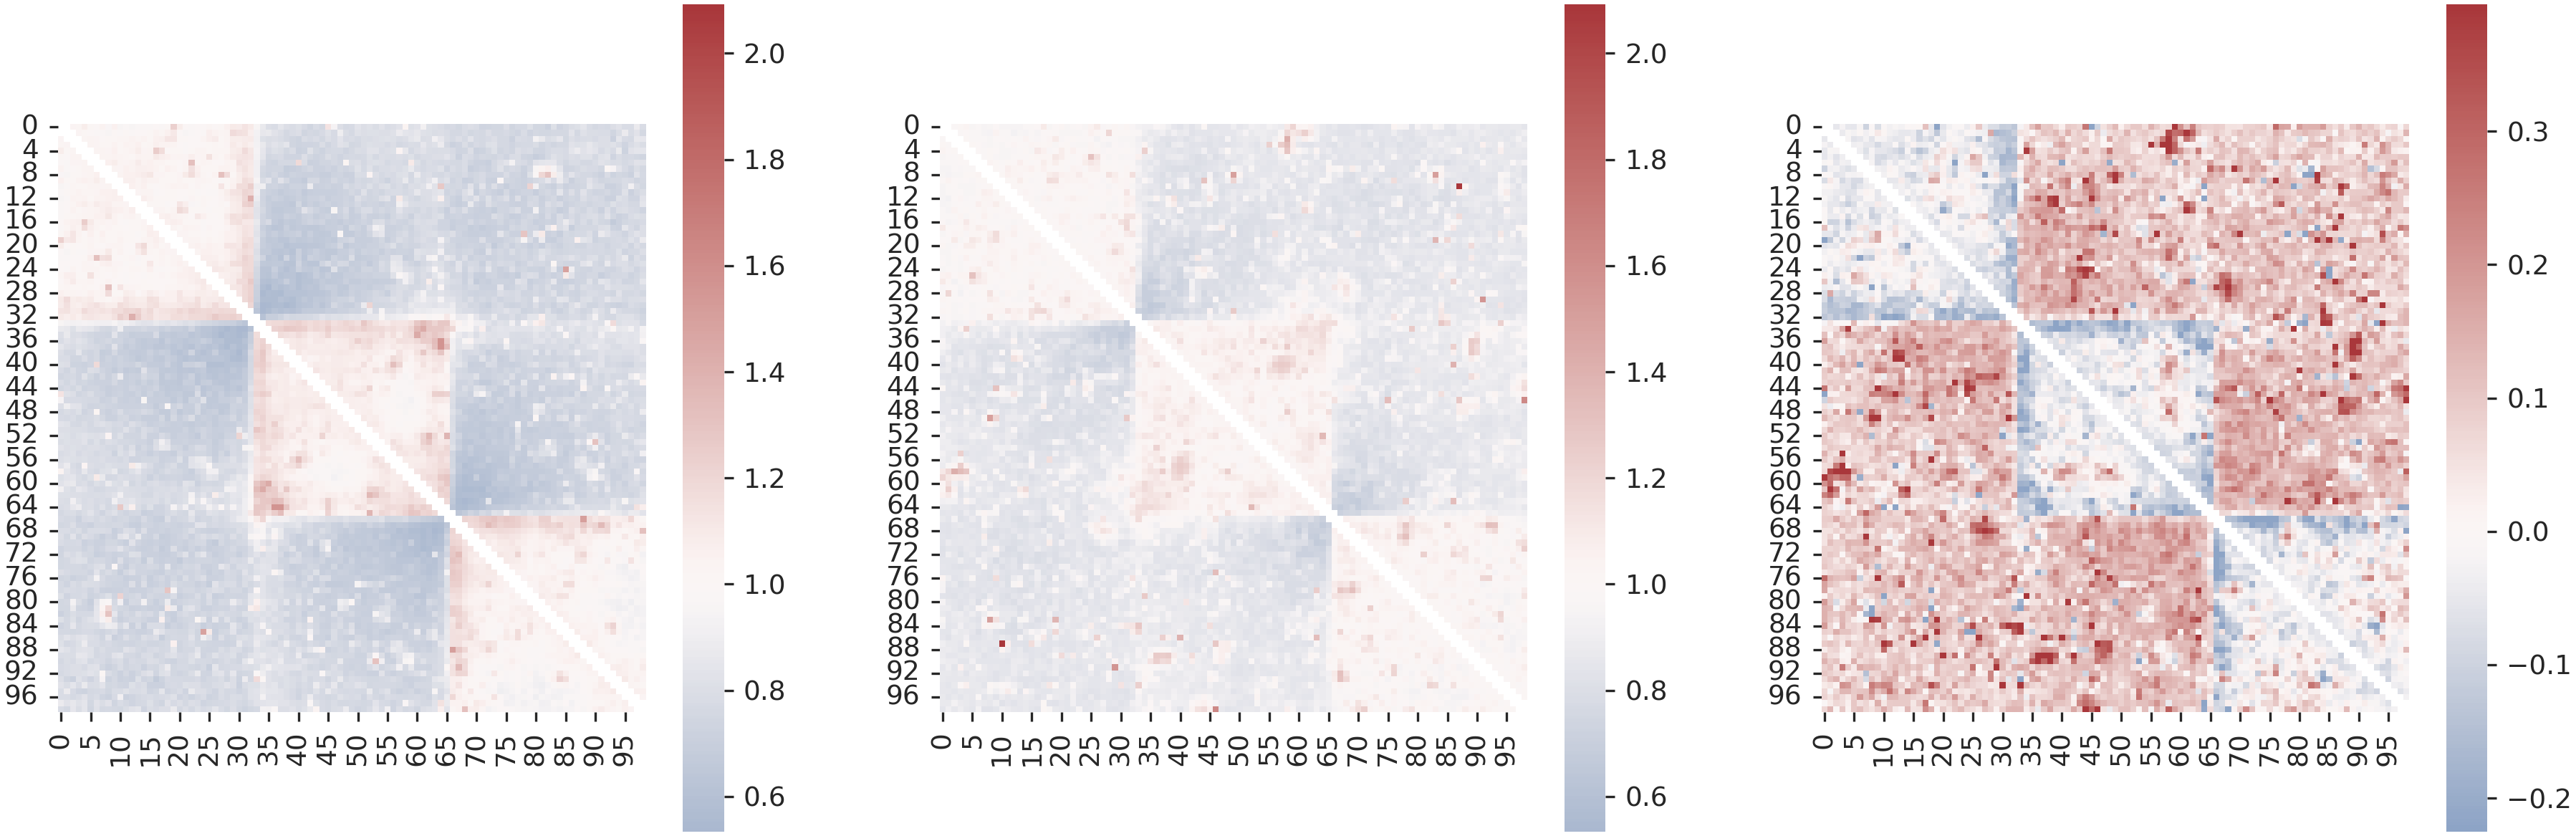

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) 

vmin = min(np.nanmin(pup_s1['data'][0]), np.nanmin(pup_s2['data'][0]))
vmax = max(np.nanmax(pup_s1['data'][0]), np.nanmax(pup_s2['data'][0]))

sns.heatmap(pup_s1['data'][0], cmap='vlag', center=1, square=True, ax=axs[0], vmin=vmin, vmax=vmax)
sns.heatmap(pup_s2['data'][0], cmap='vlag', center=1, square=True, ax=axs[1], vmin=vmin, vmax=vmax)
diff_mtx = pup_s2['data'][0] - pup_s1['data'][0]

diff_vmin = np.nanpercentile(diff_mtx, 1)
diff_vmax = np.nanpercentile(diff_mtx, 99)

sns.heatmap(diff_mtx, cmap='vlag', center=0, square=True, ax=axs[2], vmin=diff_vmin, vmax=diff_vmax)